# TCC: 03 - Análise Exploratória e Fusão de Bases (Merge Longitudinal)

Neste notebook, iniciamos a exploração visual das duas grandes bases já padronizadas (SIH e CNES) e realizamos o cruzamento rigoroso utilizando **Data (Mês/Ano) + Hospital** para evitar data-leakage e garantir a foto histórica exata da infraestrutura hospitalar.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import os
import sys

# Adiciona a raiz do projeto
ROOT = Path(os.getcwd()).parent
sys.path.insert(0, str(ROOT))

INTERIM = ROOT / 'data' / 'interim'
PROCESSED = ROOT / 'data' / 'processed'

sns.set_theme(style="whitegrid", palette="muted")

## 1. Carregamento das Bases de Modelagem

In [2]:
# Carrega apenas as bases prontas para modelagem (sem _cod)
df_sih = pd.read_csv(INTERIM / "sih_iam_modelagem.csv", low_memory=False)
df_cnes = pd.read_csv(INTERIM / "cnes_hospitais_modelagem.csv", low_memory=False)

print(f"SIH-IAM: {df_sih.shape[0]:,} internações")
print(f"CNES:    {df_cnes.shape[0]:,} fotos hospitalares (meses)")

SIH-IAM: 415,367 internações
CNES:    62,552 fotos hospitalares (meses)


## 2. Análise Exploratória Rápida (EDA)

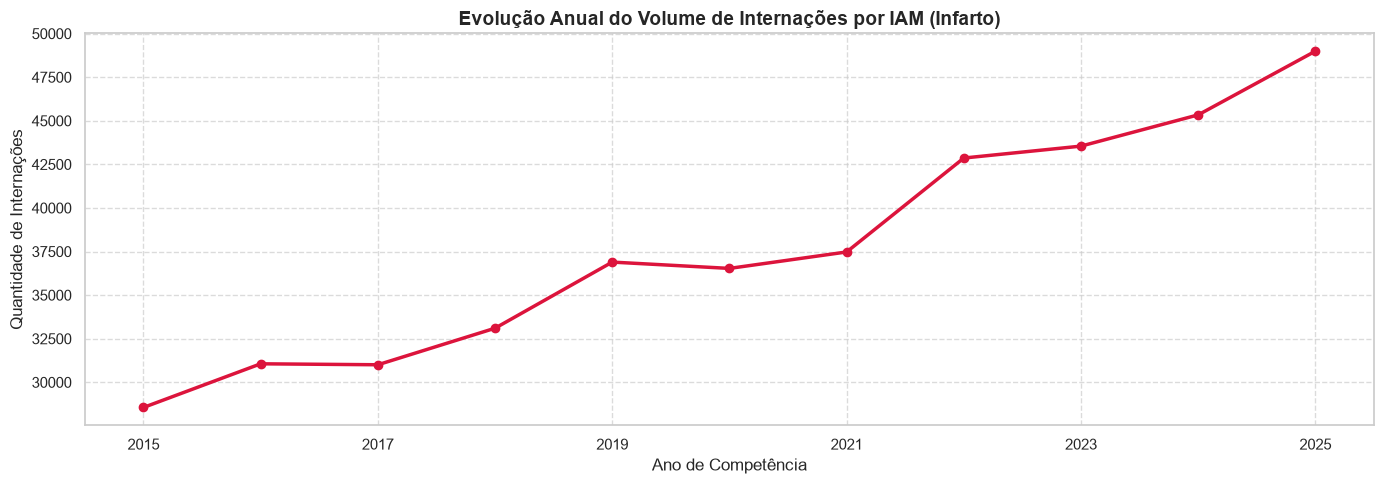

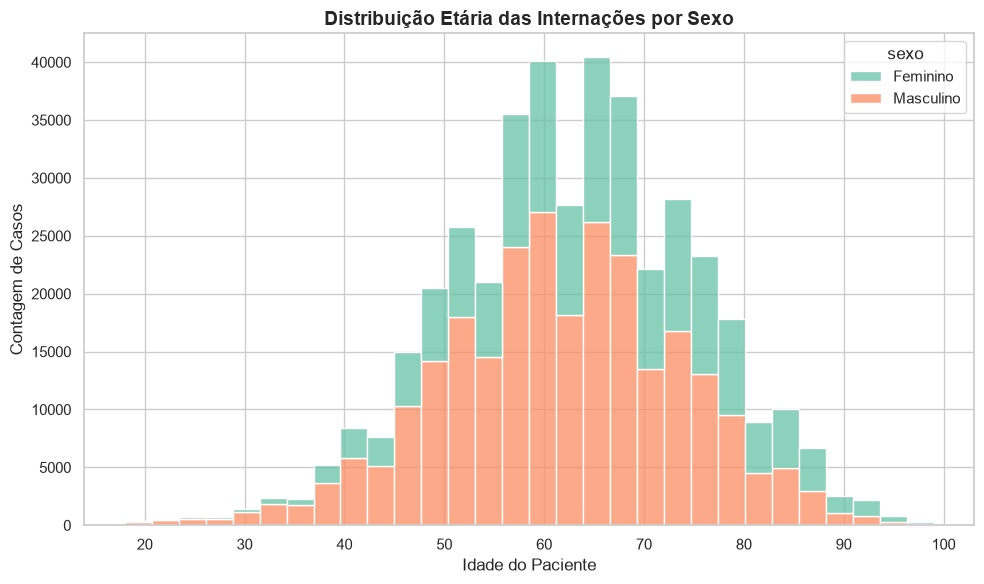

/tmp/ipykernel_942661/3694891869.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x=desfecho, palette='Reds_r')


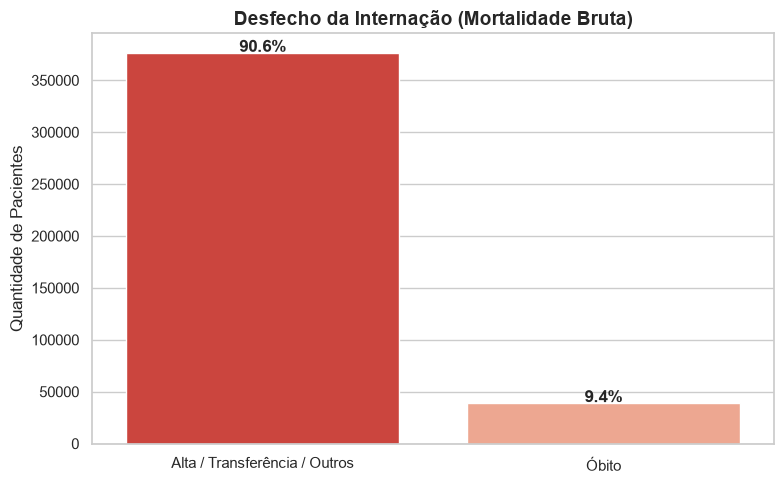

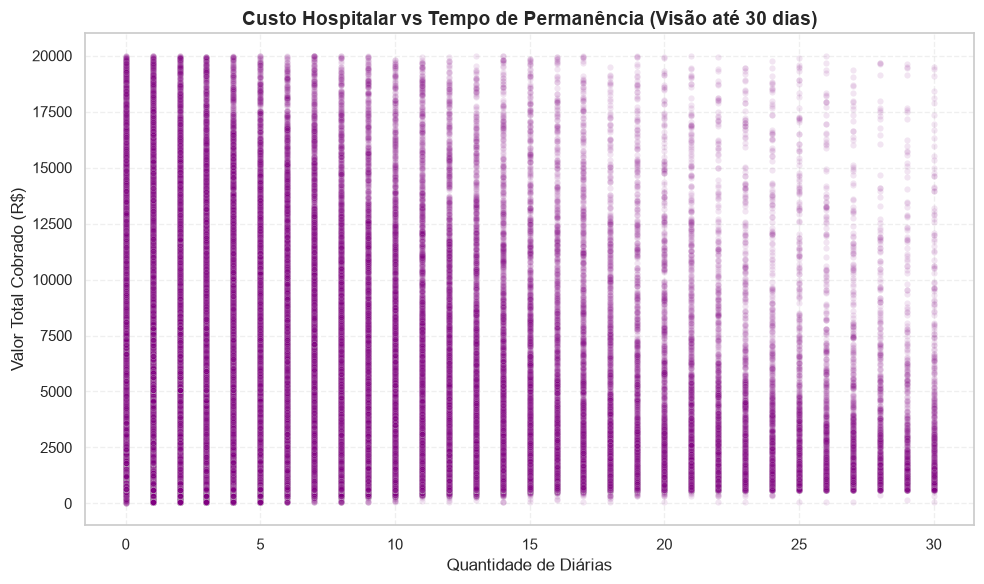

In [4]:
# 1. Evolução temporal do IAM (Visão Longitudinal)
df_sih['ano_competencia'] = df_sih['ano_competencia'].astype(str).str.replace('.0', '', regex=False)
df_sih['mes_competencia'] = df_sih['mes_competencia'].astype(str).str.replace('.0', '', regex=False).str.zfill(2)
df_sih['competencia'] = df_sih['ano_competencia'] + df_sih['mes_competencia']

plt.figure(figsize=(14, 5))
# Para o gráfico ficar legível, vamos agrupar apenas por ano
df_sih.groupby('ano_competencia').size().plot(kind='line', marker='o', color='crimson', linewidth=2.5)
plt.title("Evolução Anual do Volume de Internações por IAM (Infarto)", fontsize=14, fontweight='bold')
plt.ylabel("Quantidade de Internações")
plt.xlabel("Ano de Competência")
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# 2. Distribuição Etária por Sexo
plt.figure(figsize=(10, 6))
df_sih['idade_num'] = pd.to_numeric(df_sih['idade'], errors='coerce')
sns.histplot(data=df_sih.dropna(subset=['idade_num', 'sexo']), 
             x='idade_num', hue='sexo', multiple='stack', bins=30, palette='Set2')
plt.title("Distribuição Etária das Internações por Sexo", fontsize=14, fontweight='bold')
plt.xlabel("Idade do Paciente")
plt.ylabel("Contagem de Casos")
plt.tight_layout()
plt.show()

# 3. Desfecho Hospitalar (Mortalidade vs Alta)
plt.figure(figsize=(8, 5))
obito = df_sih['motivo_saida'].str.contains('Óbito', na=False, case=False)
desfecho = obito.map({True: 'Óbito', False: 'Alta / Transferência / Outros'})

# Calcula porcentagens para exibir no gráfico
contagens = desfecho.value_counts(normalize=True) * 100
ax = sns.countplot(x=desfecho, palette='Reds_r')
plt.title("Desfecho da Internação (Mortalidade Bruta)", fontsize=14, fontweight='bold')
plt.ylabel("Quantidade de Pacientes")
plt.xlabel("")

for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x() + p.get_width()/2., height + 1000,
            f'{height/len(df_sih)*100:.1f}%',
            ha="center", weight='bold')

plt.tight_layout()
plt.show()

# 4. Custo Total vs Tempo de Permanência
plt.figure(figsize=(10, 6))
df_sih['diarias'] = pd.to_numeric(df_sih['quantidade_diarias'], errors='coerce')
df_sih['custo'] = pd.to_numeric(df_sih['valor_total'], errors='coerce')

# Filtra outliers extremos para melhor visualização (foca em até 30 dias de internação)
df_plot = df_sih[(df_sih['diarias'] <= 30) & (df_sih['custo'] <= 20000)]

sns.scatterplot(data=df_plot, x='diarias', y='custo', alpha=0.1, color='purple', s=20)
plt.title("Custo Hospitalar vs Tempo de Permanência (Visão até 30 dias)", fontsize=14, fontweight='bold')
plt.xlabel("Quantidade de Diárias")
plt.ylabel("Valor Total Cobrado (R$)")
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()


## 3. Preparação das Chaves Longitudinais

In [5]:
# 1. Cria a chave de competência (YYYYMM) no SIH para coincidir com o CNES
df_sih['competencia'] = df_sih['ano_competencia'] + df_sih['mes_competencia']

# 2. Garante que os tipos das chaves sejam idênticos em ambas as bases
df_sih['codigo_cnes'] = df_sih['codigo_cnes'].astype(str).str.strip().str.zfill(7)
df_sih['competencia'] = df_sih['competencia'].astype(str).str.strip()

df_cnes['codigo_cnes'] = df_cnes['codigo_cnes'].astype(str).str.strip().str.zfill(7)
df_cnes['competencia'] = df_cnes['competencia'].astype(str).str.strip()

print("Amostra de chaves (SIH):")
print(df_sih[['codigo_cnes', 'competencia']].head())
print("\nAmostra de chaves (CNES):")
print(df_cnes[['codigo_cnes', 'competencia']].head())

Amostra de chaves (SIH):
  codigo_cnes competencia
0     2087804      201501
1     2091755      201501
2     2091755      201501
3     2091755      201501
4     2077396      201501

Amostra de chaves (CNES):
  codigo_cnes competencia
0     2077647      201501
1     2077558      201501
2     2774720      201501
3     2716593      201501
4     2080508      201501


## 4. O Grande Merge Longitudinal

Fazemos o `Left Join` usando Hospital + Mês. Assim, a infraestrutura hospitalar refletida no modelo de IA será a que existia **naquele exato mês da internação**.

In [6]:
# Left Join no nível Hospital-Mês
df_base_modelagem = pd.merge(
    df_sih,
    df_cnes,
    on=['codigo_cnes', 'competencia'],
    how='left',
    suffixes=('', '_cnes')
)

print(f"Linhas ANTES do merge:  {len(df_sih):,}")
print(f"Linhas DEPOIS do merge: {len(df_base_modelagem):,}")

# Validação de Match
# Verificamos quantos hospitais foram encontrados na base CNES naquele mês exato
taxa_match = df_base_modelagem['cep_estabelecimento'].notnull().mean() * 100
print(f"\nTaxa de sucesso do cruzamento (Match rate): {taxa_match:.2f}%")

if taxa_match < 50:
    print("\n⚠️ ALERTA: Match rate muito baixo! Isso geralmente ocorre quando a base do CNES baixada não contempla os mesmos anos/meses da base SIH.")


Linhas ANTES do merge:  415,367
Linhas DEPOIS do merge: 415,367

Taxa de sucesso do cruzamento (Match rate): 100.00%


## 5. Exportação da Base Final

In [7]:
path_base_final = PROCESSED / "base_modelagem.csv"
df_base_modelagem.to_csv(path_base_final, index=False)
print(f"✅ Base final exportada para {path_base_final}")

✅ Base final exportada para /home/carolina/Documents/TCC Documentos/TCC/data/processed/base_modelagem.csv
